# 第 05 章　簡單貝氏分類（Naive Bayesian Classification）

本 notebook 搭配網站「醫學生的機器學習入門」第 05 章使用。可以直接在 Google Colab 執行（選單「執行階段 → 全部執行」），不需安裝額外套件。

內容分三段：

1. 用程式算一次貝氏定理：盛行率、敏感度、特異度 → 陽性預測值（PPV）
2. `GaussianNB` 分類乳癌細胞核特徵（WDBC，sklearn 內建）
3. `MultinomialNB` 把醫學論文摘要分成 5 個疾病大類（Medical Abstracts TC Corpus，需網路下載）

> 圖上的文字一律用英文，因為 Colab 預設沒有中文字型。本例僅供學習，不構成臨床建議。

先印出套件版本。本教材以 Colab 的 scikit-learn 1.6 為相容底線，新版也能執行。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


## 1. 貝氏定理＝檢驗前後機率

先寫一個小函式：給盛行率、敏感度、特異度，回傳 PPV 與 NPV。用「每 10,000 人」的自然頻率來算，和你在流病課畫 2×2 表完全一樣。

In [2]:
def ppv_npv(prevalence, sensitivity, specificity, n=10_000):
    diseased = prevalence * n
    healthy = n - diseased
    tp = sensitivity * diseased          # true positive
    fn = diseased - tp                   # false negative
    tn = specificity * healthy           # true negative
    fp = healthy - tn                    # false positive
    return tp / (tp + fp), tn / (tn + fn)

for prev in [0.001, 0.01, 0.1, 0.3]:
    ppv, npv = ppv_npv(prev, sensitivity=0.90, specificity=0.95)
    print(f"prevalence {prev:>6.1%}  ->  PPV {ppv:6.1%}   NPV {npv:7.2%}")

prevalence   0.1%  ->  PPV   1.8%   NPV  99.99%
prevalence   1.0%  ->  PPV  15.4%   NPV  99.89%
prevalence  10.0%  ->  PPV  66.7%   NPV  98.84%
prevalence  30.0%  ->  PPV  88.5%   NPV  95.68%


同一支敏感度 90%、特異度 95% 的檢驗，盛行率 1% 時 PPV 只有約 15%，盛行率 30% 時卻接近 89%。檢驗本身沒變，變的是檢驗前機率。

換成勝算（odds）與概似比（likelihood ratio）的寫法：檢驗後勝算＝檢驗前勝算 × LR。連續做兩個檢驗時，**如果兩者在已知有無疾病下彼此獨立**，就可以一路乘下去——這正是 naive Bayes 的核心假設。

In [3]:
def to_odds(p):
    return p / (1 - p)

def to_prob(odds):
    return odds / (1 + odds)

sens, spec = 0.90, 0.95
lr_pos = sens / (1 - spec)               # LR+ = 18
pretest = 0.01

post1 = to_prob(to_odds(pretest) * lr_pos)
post2 = to_prob(to_odds(pretest) * lr_pos * lr_pos)   # a second, independent positive test
print(f"LR+ = {lr_pos:.1f}")
print(f"after 1 positive test : {post1:.1%}")
print(f"after 2 positive tests: {post2:.1%}  (only valid if the tests are conditionally independent)")

LR+ = 18.0
after 1 positive test : 15.4%
after 2 positive tests: 76.6%  (only valid if the tests are conditionally independent)


第一次陽性之後機率從 1% 升到約 15.4%（和上面 PPV 相同），再一次獨立的陽性升到約 76.6%。若第二個檢驗其實和第一個高度相關（例如同一種原理的兩支試劑），這樣相乘就會高估。

## 2. GaussianNB：乳癌細胞核特徵

WDBC 資料集的標籤 `0 = 惡性、1 = 良性`，和直覺相反。我們先把它翻成 `1 = 惡性`，再切出 25% 當測試集。

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True, as_frame=True)
y = (y == 0).astype(int)                 # flip: 1 = malignant, 0 = benign
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print(X_train.shape, X_test.shape, "malignant rate:", round(y.mean(), 3))

(426, 30) (143, 30) malignant rate: 0.373


訓練 `GaussianNB` 只要兩行，不需要標準化（每個特徵各自估平均與變異數，尺度不影響）。

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print("accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(confusion_matrix(y_test, y_pred))          # rows: true 0/1, cols: predicted 0/1
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"], digits=3))

accuracy: 0.944
[[90  0]
 [ 8 45]]
              precision    recall  f1-score   support

      benign      0.918     1.000     0.957        90
   malignant      1.000     0.849     0.918        53

    accuracy                          0.944       143
   macro avg      0.959     0.925     0.938       143
weighted avg      0.949     0.944     0.943       143



混淆矩陣的第二列是真正惡性的 53 例：抓到 45 例、漏掉 8 例（敏感度約 0.85），良性則全部判對。對醫學應用來說，偽陰性比偽陽性更值得注意。

模型「學到」的東西其實就是每個類別、每個特徵的平均與變異數，可以直接印出來看。

In [6]:
params = pd.DataFrame({"benign_mean": nb.theta_[0], "malignant_mean": nb.theta_[1]},
                      index=X.columns)
print("class prior:", nb.class_prior_.round(3))
params.loc[["mean radius", "mean concave points", "worst area"]].round(3)

class prior: [0.627 0.373]


,benign_mean,malignant_mean
mean radius,12.166,17.530
mean concave points,0.026,0.088
worst area,563.221,1446.654


`class_prior_` 就是訓練集中良性與惡性的比例（先驗機率）；表格是兩類各自的特徵平均（`theta_`），搭配變異數（`var_`）就決定了每一條常態曲線。預測時，模型把 30 個特徵的常態機率密度相乘，再乘上先驗。

用 5 折交叉驗證和邏輯迴歸比一比，看看這個「天真」的模型差多少。

In [7]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "GaussianNB": GaussianNB(),
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv)
    print(f"{name:20s} accuracy {scores.mean():.3f} (+/- {scores.std():.3f})")

GaussianNB           accuracy 0.939 (+/- 0.023)
LogisticRegression   accuracy 0.974 (+/- 0.017)


GaussianNB 大約 0.94，邏輯迴歸約 0.97～0.98。NB 不是最強，但幾乎不用調參數、訓練一瞬間，很適合當基準線（baseline）。

### 機率輸出不要當真

WDBC 有很多高度相關的特徵（半徑、周長、面積幾乎是同一件事），違反條件獨立假設，於是同一份證據被重複相乘，機率被推到極端。

corr(mean radius, mean perimeter) = 0.998
share of predictions < 1% or > 99%: 0.958
misclassified cases: 8
their predicted P(malignant): [0.     0.     0.0022 0.0026 0.0032 0.0156 0.1963 0.2041]


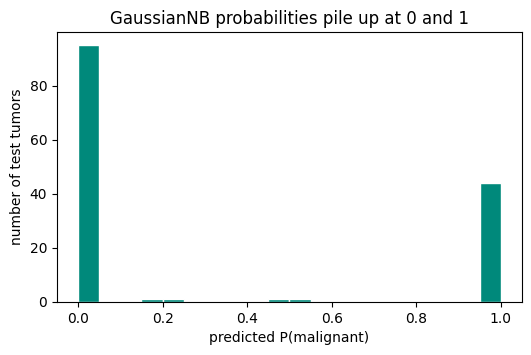

In [8]:
proba = nb.predict_proba(X_test)[:, 1]          # predicted probability of malignant
print("corr(mean radius, mean perimeter) =", round(X["mean radius"].corr(X["mean perimeter"]), 3))
print("share of predictions < 1% or > 99%:", round(np.mean((proba < 0.01) | (proba > 0.99)), 3))

wrong = y_pred != y_test.to_numpy()
print("misclassified cases:", wrong.sum())
print("their predicted P(malignant):", np.sort(proba[wrong]).round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(proba, bins=20, range=(0, 1), color="#00897B", edgecolor="white")
ax.set_xlabel("predicted P(malignant)")
ax.set_ylabel("number of test tumors")
ax.set_title("GaussianNB probabilities pile up at 0 and 1")
plt.show()

超過九成的預測落在 <1% 或 >99%；而被判錯的 8 例中，有 5 例模型給的惡性機率不到 1%。分類結果可以參考，但 `predict_proba` 的數字不能當成「這顆腫瘤的惡性風險」。

## 3. MultinomialNB：醫學摘要文字分類

資料來自 Medical Abstracts TC Corpus（sebischair，GitHub），約 1.4 萬篇醫學摘要，標為 5 個疾病大類。需要網路下載（約 10 秒）。

In [9]:
base = "https://raw.githubusercontent.com/sebischair/Medical-Abstracts-TC-Corpus/main/"
try:
    train_df = pd.read_csv(base + "medical_tc_train.csv")
    test_df = pd.read_csv(base + "medical_tc_test.csv")
except Exception as e:
    raise RuntimeError(
        "下載 Medical Abstracts 失敗，請確認網路連線，或稍後再執行此格。原始錯誤：" + str(e))

label_names = {1: "neoplasms", 2: "digestive", 3: "nervous", 4: "cardiovascular", 5: "general"}
print(train_df.shape, test_df.shape)
print(train_df["condition_label"].map(label_names).value_counts())
print(train_df["medical_abstract"].iloc[0][:300], "...")

(11550, 2) (2888, 2)
condition_label
general           3844
neoplasms         2530
cardiovascular    2441
nervous           1540
digestive         1195
Name: count, dtype: int64
Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were is ...


先用三句玩具句子看看詞袋模型（bag-of-words）在做什麼：每個字變成一欄，數它出現幾次，**字的順序被丟掉**。

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

toy = ["chest pain and dyspnea",
       "tumor biopsy shows carcinoma",
       "chest tumor with pain"]
vec = CountVectorizer()
counts = vec.fit_transform(toy)
pd.DataFrame(counts.toarray(), columns=vec.get_feature_names_out(), index=["doc1", "doc2", "doc3"])

,and,biopsy,carcinoma,chest,dyspnea,pain,shows,tumor,with
doc1,1,0,0,1,1,1,0,0,0
doc2,0,1,1,0,0,0,1,1,0
doc3,0,0,0,1,0,1,0,1,1


接著把「詞袋 → MultinomialNB」串成 Pipeline，在真正的摘要上訓練。`stop_words="english"` 移除 the、and 等虛詞，`min_df=2` 忽略只出現一次的字。

test accuracy: 0.587


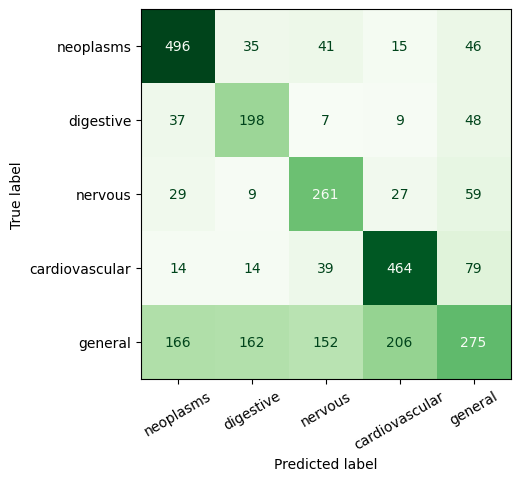

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay

text_clf = make_pipeline(CountVectorizer(stop_words="english", min_df=2), MultinomialNB())
text_clf.fit(train_df["medical_abstract"], train_df["condition_label"])
pred = text_clf.predict(test_df["medical_abstract"])
print("test accuracy:", round(accuracy_score(test_df["condition_label"], pred), 3))

ConfusionMatrixDisplay.from_predictions(
    test_df["condition_label"], pred,
    display_labels=list(label_names.values()), cmap="Greens", colorbar=False,
    xticks_rotation=30)
plt.show()

整體準確度約 0.59。看混淆矩陣就知道問題在哪：「general pathological conditions」是雜項類別，大量被分到其他四類，其他四類彼此的界線反而清楚得多。

每個類別的 `feature_log_prob_` 是「在這一類裡，每個字出現的機率（取對數）」。印出各類最具代表性的字，模型就不再是黑盒子。

In [12]:
vec = text_clf.named_steps["countvectorizer"]
mnb = text_clf.named_steps["multinomialnb"]
words = vec.get_feature_names_out()
for i, label in enumerate(mnb.classes_):
    top = np.argsort(mnb.feature_log_prob_[i])[::-1][:8]
    print(f"{label_names[label]:15s}", ", ".join(words[top]))

neoplasms       patients, cancer, cell, tumor, cells, carcinoma, tumors, disease
digestive       patients, disease, liver, treatment, group, study, patient, gastric
nervous         patients, disease, treatment, group, pain, study, patient, brain
cardiovascular  patients, coronary, pressure, blood, ventricular, group, disease, artery
general         patients, group, disease, treatment, study, patient, cases, acute


腫瘤類出現 cancer、tumor，心血管類出現 coronary、blood、artery，大致符合醫學直覺；但也有 patients、study 這種每一類都常見的字，這是只數次數的詞袋模型的限制。

比較三種 NB 變體：Multinomial（數次數）、Bernoulli（只看有沒有出現）、Complement（為類別不平衡設計的 Multinomial 變形）。

In [13]:
from sklearn.naive_bayes import BernoulliNB, ComplementNB

variants = {
    "MultinomialNB": make_pipeline(CountVectorizer(stop_words="english", min_df=2), MultinomialNB()),
    "BernoulliNB": make_pipeline(CountVectorizer(stop_words="english", min_df=2, binary=True), BernoulliNB()),
    "ComplementNB": make_pipeline(CountVectorizer(stop_words="english", min_df=2), ComplementNB()),
}
for name, model in variants.items():
    model.fit(train_df["medical_abstract"], train_df["condition_label"])
    acc = accuracy_score(test_df["condition_label"], model.predict(test_df["medical_abstract"]))
    print(f"{name:14s} test accuracy {acc:.3f}")

MultinomialNB  test accuracy 0.587


BernoulliNB    test accuracy 0.559


ComplementNB   test accuracy 0.595


三者差距只有幾個百分點，都在 0.56～0.60 之間；這份資料的瓶頸是類別本身模糊，不是選哪個變體。

最後丟一句自己寫的句子進去試試。

In [14]:
new_docs = ["Patients with acute myocardial infarction underwent coronary angiography.",
            "Resection of hepatocellular carcinoma improved survival."]
for doc, label in zip(new_docs, text_clf.predict(new_docs)):
    print(f"{label_names[label]:15s} <- {doc}")

cardiovascular  <- Patients with acute myocardial infarction underwent coronary angiography.
neoplasms       <- Resection of hepatocellular carcinoma improved survival.


## 動手試試

1. 在第 1 段把 `specificity` 從 0.95 改成 0.99，盛行率 1% 時 PPV 變成多少？（提示：偽陽性人數會剩原本的五分之一）
2. 在 GaussianNB 那段只用 `["mean radius", "mean texture", "mean smoothness"]` 三個相關性較低的特徵訓練，比較準確度與 `predict_proba` 落在極端值的比例。
3. 把 `CountVectorizer` 換成 `TfidfVectorizer`，或在 `MultinomialNB(alpha=...)` 試 0.1 與 5，觀察測試準確度如何變化。